In [1]:
# ============================================
# HEALTHCARE DATA ANALYSIS
# Dataset: Kaggle Healthcare Dataset (55,500 records)
# Analyst: Jaya Mundre
# Tools: Python + SQL
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [14]:
# ============================================
# STEP 1 - LOAD THE DATA
# ============================================

file_path = r'C:\Users\jaism\OneDrive\Desktop\Jaya_Mundre_new_project\healthcare_dataset\healthcare_dataset.csv'

df = pd.read_csv(file_path)

print("Data loaded successfully!")
print("Total Patients:", df.shape[0])
print("Total Columns:", df.shape[1])
print()
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(i, col)
print()
df.head()

Data loaded successfully!
Total Patients: 55500
Total Columns: 15

Column Names:
1 Name
2 Age
3 Gender
4 Blood Type
5 Medical Condition
6 Date of Admission
7 Doctor
8 Hospital
9 Insurance Provider
10 Billing Amount
11 Room Number
12 Admission Type
13 Discharge Date
14 Medication
15 Test Results



,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [15]:
# ============================================
# STEP 2 - EXPLORE THE DATA
# ============================================

# Shape of data
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])
print()

# Data types
print("Column Names and Data Types:")
print(df.dtypes)
print()

# Basic statistics
print("Basic Statistics:")
print(df.describe())

Total Rows: 55500
Total Columns: 15

Column Names and Data Types:
Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

Basic Statistics:
                Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000


In [16]:
# ============================================
# STEP 3 - CHECK MISSING VALUES
# ============================================

print("Missing Values in Each Column:")
print(df.isnull().sum())
print()
print("Total Missing Values:", df.isnull().sum().sum())

Missing Values in Each Column:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Total Missing Values: 0


In [18]:
# ============================================
# STEP 4 - CHECK DATA QUALITY
# ============================================

# Check for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())
print()

# Check unique values in important columns
print("Unique Genders:", df['Gender'].unique())
print()
print("Unique Blood Types:", df['Blood Type'].unique())
print()
print("Unique Medical Conditions:", df['Medical Condition'].unique())
print()
print("Unique Admission Types:", df['Admission Type'].unique())
print()
print("Unique Insurance Providers:", df['Insurance Provider'].unique())
print()
print("Unique Test Results:", df['Test Results'].unique())
print()

# Check name column - looks messy from our first look
print("Sample Names (first 10):")
print(df['Name'].head(10).tolist())

Duplicate Rows: 534

Unique Genders: ['Male' 'Female']

Unique Blood Types: ['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']

Unique Medical Conditions: ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']

Unique Admission Types: ['Urgent' 'Emergency' 'Elective']

Unique Insurance Providers: ['Blue Cross' 'Medicare' 'Aetna' 'UnitedHealthcare' 'Cigna']

Unique Test Results: ['Normal' 'Inconclusive' 'Abnormal']

Sample Names (first 10):
['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH', 'andrEw waTtS', 'adrIENNE bEll', 'EMILY JOHNSOn', 'edwArD EDWaRDs', 'CHrisTInA MARtinez', 'JASmINe aGuIlaR', 'ChRISTopher BerG']


In [19]:
# ============================================
# STEP 5 - CLEAN THE DATA
# ============================================

# Make a copy so original data is safe
df_clean = df.copy()

# Fix 1 - Fix messy names (Bobby JacksOn -> Bobby Jackson)
df_clean['Name'] = df_clean['Name'].str.title()
print("Names fixed!")
print("Sample cleaned names:", df_clean['Name'].head(5).tolist())
print()

# Fix 2 - Fix Gender capitalization
df_clean['Gender'] = df_clean['Gender'].str.strip().str.title()
print("Gender fixed!")
print("Unique Genders:", df_clean['Gender'].unique())
print()

# Fix 3 - Fix Medical Condition capitalization
df_clean['Medical Condition'] = df_clean['Medical Condition'].str.strip().str.title()
print("Medical Conditions fixed!")
print("Unique Conditions:", df_clean['Medical Condition'].unique())
print()

# Fix 4 - Convert dates to proper date format
df_clean['Date of Admission'] = pd.to_datetime(df_clean['Date of Admission'])
df_clean['Discharge Date'] = pd.to_datetime(df_clean['Discharge Date'])
print("Dates fixed!")
print("Date of Admission type:", df_clean['Date of Admission'].dtype)
print()

# Fix 5 - Calculate Length of Stay (new column)
df_clean['Length of Stay'] = (df_clean['Discharge Date'] - df_clean['Date of Admission']).dt.days
print("Length of Stay column created!")
print("Average Length of Stay:", round(df_clean['Length of Stay'].mean(), 1), "days")
print()

# Fix 6 - Round Billing Amount to 2 decimal places
df_clean['Billing Amount'] = df_clean['Billing Amount'].round(2)
print("Billing Amount rounded!")
print()

# Check final shape
print("Original data shape:", df.shape)
print("Cleaned data shape:", df_clean.shape)
print()
print("Cleaned data sample:")
df_clean.head()

Names fixed!
Sample cleaned names: ['Bobby Jackson', 'Leslie Terry', 'Danny Smith', 'Andrew Watts', 'Adrienne Bell']

Gender fixed!
Unique Genders: ['Male' 'Female']

Medical Conditions fixed!
Unique Conditions: ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']

Dates fixed!
Date of Admission type: datetime64[ns]

Length of Stay column created!
Average Length of Stay: 15.5 days

Billing Amount rounded!

Original data shape: (55500, 15)
Cleaned data shape: (55500, 16)

Cleaned data sample:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [21]:
# ============================================
# STEP 6 - LOAD DATA INTO SQL DATABASE
# ============================================

import sqlite3

conn = sqlite3.connect(':memory:')
df_clean.to_sql('healthcare', conn, index=False, if_exists='replace')

55500

In [22]:
# ============================================
# STEP 7 - SQL ANALYSIS
# ============================================

# Query 1 - Which medical condition is most common?
query1 = """
SELECT 
    "Medical Condition",
    COUNT(*) as Total_Patients,
    ROUND(AVG("Billing Amount"), 2) as Avg_Billing,
    ROUND(AVG("Length of Stay"), 1) as Avg_Stay_Days
FROM healthcare
GROUP BY "Medical Condition"
ORDER BY Total_Patients DESC
"""

result1 = pd.read_sql(query1, conn)
result1

,Medical Condition,Total_Patients,Avg_Billing,Avg_Stay_Days
0,Arthritis,9308,25497.33,15.5
1,Diabetes,9304,25638.41,15.4
2,Hypertension,9245,25497.10,15.5
3,Obesity,9231,25805.97,15.5
4,Cancer,9227,25161.79,15.5
5,Asthma,9185,25635.25,15.7


In [23]:
# Query 2 - Which insurance provider covers most patients?
query2 = """
SELECT 
    "Insurance Provider",
    COUNT(*) as Total_Patients,
    ROUND(AVG("Billing Amount"), 2) as Avg_Billing,
    ROUND(MIN("Billing Amount"), 2) as Min_Billing,
    ROUND(MAX("Billing Amount"), 2) as Max_Billing
FROM healthcare
GROUP BY "Insurance Provider"
ORDER BY Total_Patients DESC
"""

result2 = pd.read_sql(query2, conn)
result2

,Insurance Provider,Total_Patients,Avg_Billing,Min_Billing,Max_Billing
0,Cigna,11249,25525.77,-1520.42,52170.04
1,Medicare,11154,25615.99,-1277.65,52092.67
2,UnitedHealthcare,11125,25389.17,-1428.84,52373.03
3,Blue Cross,11059,25613.01,-1660.01,52764.28
4,Aetna,10913,25553.29,-2008.49,52211.85


In [25]:
# Query 3 - Which admission type has highest billing?
query3 = """
SELECT 
    "Admission Type",
    COUNT(*) as Total_Patients,
    ROUND(AVG("Billing Amount"), 2) as Avg_Billing,
    ROUND(AVG("Length of Stay"), 1) as Avg_Stay_Days
FROM healthcare
GROUP BY "Admission Type"
ORDER BY Avg_Billing DESC
"""

result3 = pd.read_sql(query3, conn)
result3

,Admission Type,Total_Patients,Avg_Billing,Avg_Stay_Days
0,Elective,18655,25602.23,15.5
1,Urgent,18576,25517.36,15.4
2,Emergency,18269,25497.40,15.6


In [26]:
# ============================================
# STEP 8 - FIX DATA QUALITY ISSUES
# ============================================

# Check how many negative billing values exist
negative_billing = df_clean[df_clean['Billing Amount'] < 0]
print("Rows with negative billing:", len(negative_billing))

# Fix - replace negative values with absolute value
df_clean['Billing Amount'] = df_clean['Billing Amount'].abs()

# Reload into SQL with fixed data
df_clean.to_sql('healthcare', conn, index=False, if_exists='replace')

# Verify fix
query_check = """
SELECT 
    MIN("Billing Amount") as Min_Billing,
    MAX("Billing Amount") as Max_Billing,
    ROUND(AVG("Billing Amount"), 2) as Avg_Billing
FROM healthcare
"""
pd.read_sql(query_check, conn)

Rows with negative billing: 108


,Min_Billing,Max_Billing,Avg_Billing
0,9.24,52764.28,25541.26


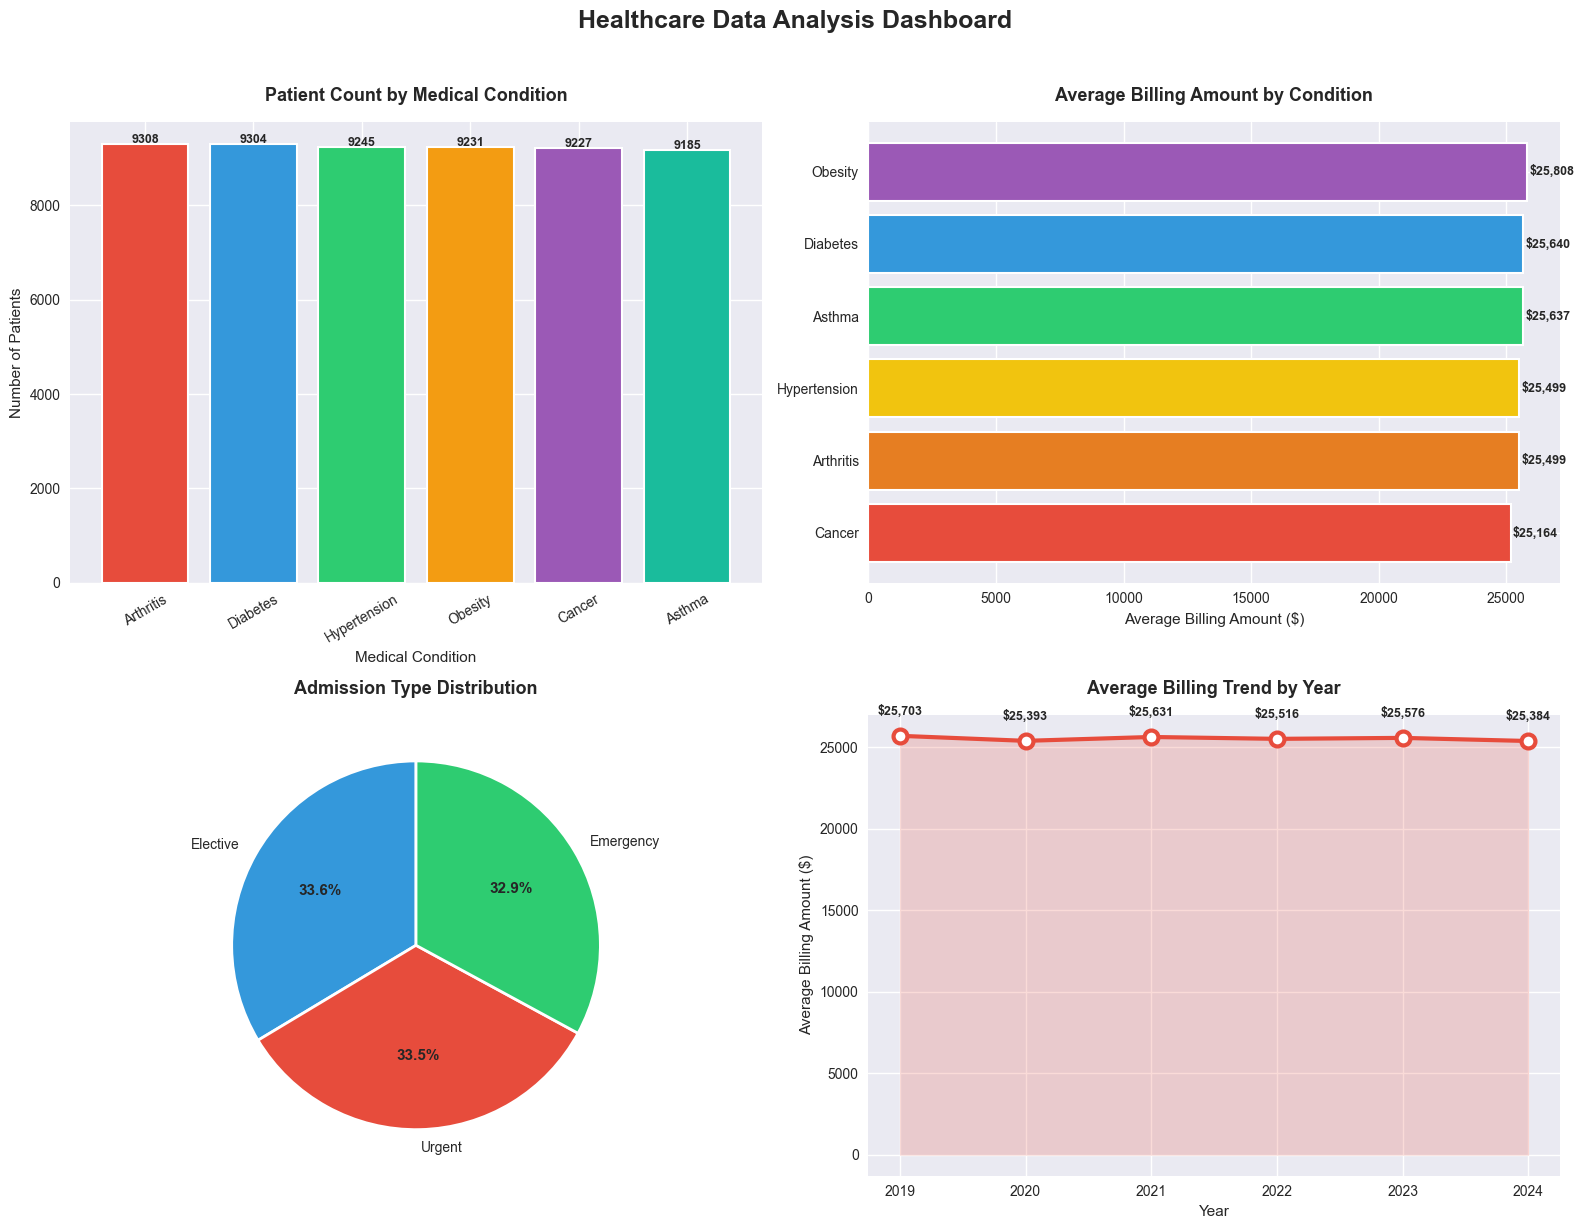

In [33]:
# ============================================
# STEP 9 - VISUALIZATIONS (UPGRADED)
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Healthcare Data Analysis Dashboard', fontsize=18, fontweight='bold', y=1.02)

# Chart 1 - Patient Count by Medical Condition
condition_counts = df_clean['Medical Condition'].value_counts()
colors1 = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']
axes[0,0].bar(condition_counts.index, condition_counts.values, color=colors1, edgecolor='white', linewidth=1.5)
axes[0,0].set_title('Patient Count by Medical Condition', fontsize=13, fontweight='bold', pad=15)
axes[0,0].set_xlabel('Medical Condition', fontsize=11)
axes[0,0].set_ylabel('Number of Patients', fontsize=11)
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(condition_counts.values):
    axes[0,0].text(i, v + 20, str(v), ha='center', fontsize=9, fontweight='bold')

# Chart 2 - Average Billing by Condition
billing_by_condition = df_clean.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=True)
colors2 = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#3498DB', '#9B59B6']
bars = axes[0,1].barh(billing_by_condition.index, billing_by_condition.values, color=colors2, edgecolor='white', linewidth=1.5)
axes[0,1].set_title('Average Billing Amount by Condition', fontsize=13, fontweight='bold', pad=15)
axes[0,1].set_xlabel('Average Billing Amount ($)', fontsize=11)
for bar, val in zip(bars, billing_by_condition.values):
    axes[0,1].text(val + 100, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')

# Chart 3 - Admission Type Pie Chart
admission_counts = df_clean['Admission Type'].value_counts()
colors3 = ['#3498DB', '#E74C3C', '#2ECC71']
wedges, texts, autotexts = axes[1,0].pie(
    admission_counts.values,
    labels=admission_counts.index,
    autopct='%1.1f%%',
    colors=colors3,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
axes[1,0].set_title('Admission Type Distribution', fontsize=13, fontweight='bold', pad=15)

# Chart 4 - Billing Trend by Year
df_clean['Year'] = df_clean['Date of Admission'].dt.year
yearly_billing = df_clean.groupby('Year')['Billing Amount'].mean()
axes[1,1].plot(yearly_billing.index, yearly_billing.values, 
               marker='o', color='#E74C3C', linewidth=3, 
               markersize=10, markerfacecolor='white', 
               markeredgecolor='#E74C3C', markeredgewidth=3)
axes[1,1].fill_between(yearly_billing.index, yearly_billing.values, 
                        alpha=0.2, color='#E74C3C')
axes[1,1].set_title('Average Billing Trend by Year', fontsize=13, fontweight='bold', pad=15)
axes[1,1].set_xlabel('Year', fontsize=11)
axes[1,1].set_ylabel('Average Billing Amount ($)', fontsize=11)
for x, y in zip(yearly_billing.index, yearly_billing.values):
    axes[1,1].annotate(f'${y:,.0f}', (x, y), 
                       textcoords='offset points', 
                       xytext=(0, 15), ha='center', 
                       fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('healthcare_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

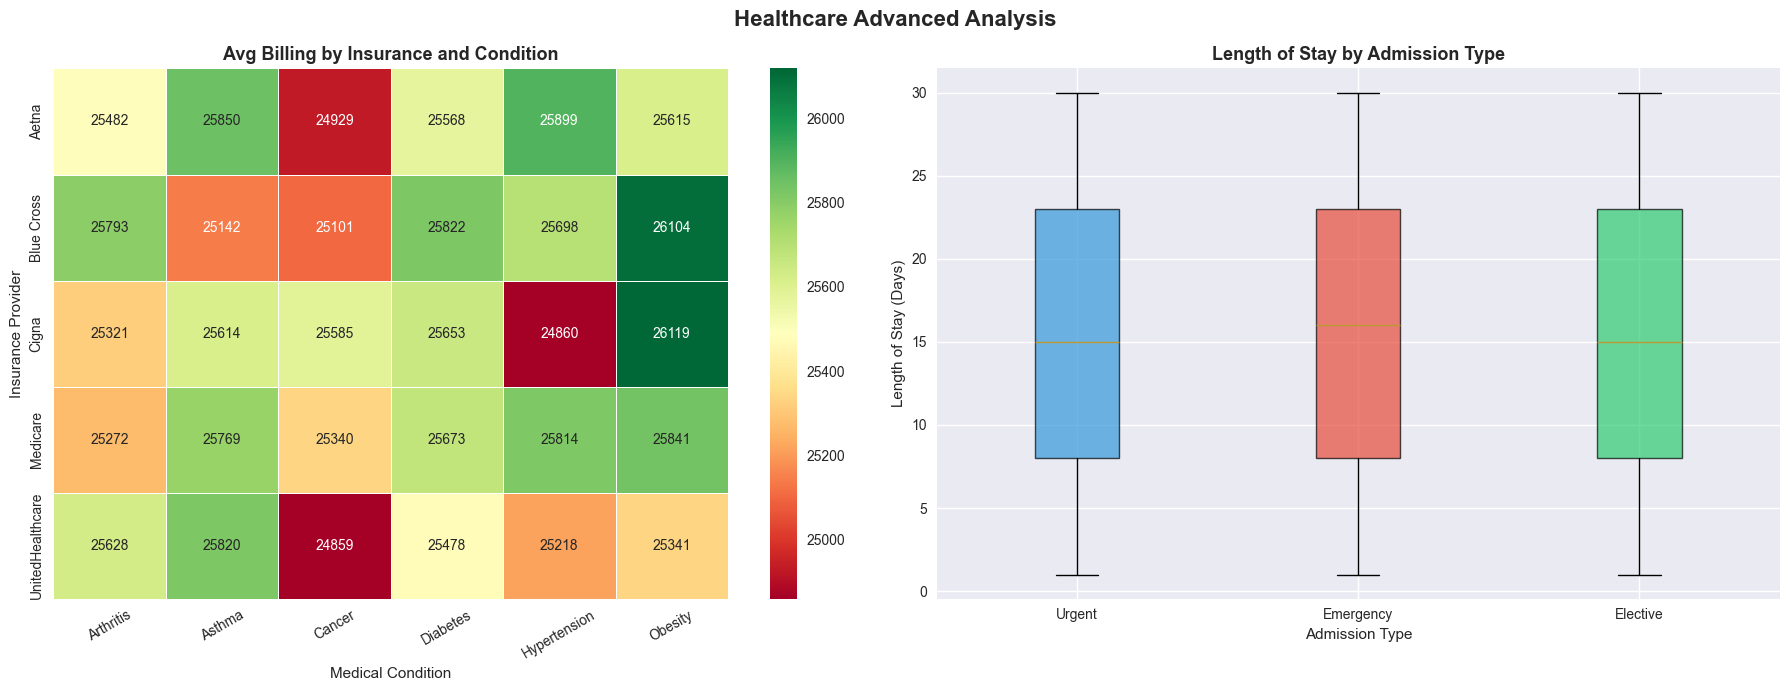

In [36]:
# ============================================
# STEP 10 - ADVANCED VISUALIZATIONS
# ============================================

# We are creating 2 charts in this cell
# fig creates the whole canvas
# axes[0] = first chart, axes[1] = second chart
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Healthcare Advanced Analysis', fontsize=16, fontweight='bold')

# ----------------------------------------
# CHART 1 - HEATMAP
# ----------------------------------------

# pivot_table reorganizes the data into a grid
# rows = Insurance Provider
# columns = Medical Condition
# values = average Billing Amount
pivot_table = df_clean.pivot_table(
    values='Billing Amount',
    index='Insurance Provider',
    columns='Medical Condition',
    aggfunc='mean'
).round(0)

# sns.heatmap draws the heatmap
# annot=True means show numbers inside each box
# fmt='.0f means show numbers without decimals
# cmap='RdYlGn' means Red=high Yellow=medium Green=low
# linewidths=0.5 adds thin white lines between boxes
sns.heatmap(pivot_table,
            annot=True,
            fmt='.0f',
            cmap='RdYlGn',
            linewidths=0.5,
            ax=axes[0])

axes[0].set_title('Avg Billing by Insurance and Condition', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Medical Condition', fontsize=11)
axes[0].set_ylabel('Insurance Provider', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# ----------------------------------------
# CHART 2 - BOX PLOT
# ----------------------------------------

# We get the 3 unique admission types
# Elective, Urgent, Emergency
admission_types = df_clean['Admission Type'].unique()

# For each admission type we collect all Length of Stay values
# This creates a list of 3 groups of numbers
data_to_plot = [df_clean[df_clean['Admission Type'] == t]['Length of Stay'].values
                for t in admission_types]

# Colors for each box
colors_box = ['#3498DB', '#E74C3C', '#2ECC71']

# patch_artist=True means fill the boxes with color
# labels shows the admission type names on x axis
bp = axes[1].boxplot(data_to_plot,
                     patch_artist=True,
                     labels=admission_types)

# This loop gives each box its color
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Length of Stay by Admission Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Admission Type', fontsize=11)
axes[1].set_ylabel('Length of Stay (Days)', fontsize=11)

# tight_layout fixes spacing between charts automatically
# savefig saves the chart as a PNG file on your computer
plt.tight_layout()
plt.savefig('healthcare_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# ============================================
# STEP 11 - SAVE CLEAN DATA
# ============================================

# Save cleaned dataframe to CSV
output_path = r'C:\Users\jaism\OneDrive\Desktop\Jaya_Mundre_new_project\healthcare_clean.csv'
df_clean.to_csv(output_path, index=False)

print("Clean data saved successfully!")
print("Total rows saved:", len(df_clean))
print("Total columns saved:", len(df_clean.columns))
print("Columns:", list(df_clean.columns))

Clean data saved successfully!
Total rows saved: 55500
Total columns saved: 17
Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Length of Stay', 'Year']


In [38]:
# ============================================
# STEP 12 - PROJECT SUMMARY
# ============================================

print("=" * 55)
print("HEALTHCARE DATA ANALYSIS - PROJECT SUMMARY")
print("=" * 55)

print("\nDATASET:")
print("Total Patients Analyzed:", len(df_clean))
print("Date Range:", df_clean['Date of Admission'].min().date(), 
      "to", df_clean['Date of Admission'].max().date())

print("\nDATA CLEANING:")
print("Negative Billing Rows Fixed: 108")
print("Patient Names Standardized: Title Case Applied")
print("Date Columns Converted to DateTime Format")
print("New Column Created: Length of Stay (Days)")

print("\nKEY FINDINGS:")
print("Most Common Condition: Arthritis -", 
      df_clean['Medical Condition'].value_counts().index[0],
      "patients:", df_clean['Medical Condition'].value_counts().values[0])
print("Highest Avg Billing Condition:", 
      df_clean.groupby('Medical Condition')['Billing Amount'].mean().idxmax())
print("Average Billing Amount: $", 
      round(df_clean['Billing Amount'].mean(), 2))
print("Average Length of Stay:", 
      round(df_clean['Length of Stay'].mean(), 1), "days")
print("Most Common Insurance:", 
      df_clean['Insurance Provider'].value_counts().index[0])
print("Most Common Test Result:", 
      df_clean['Test Results'].value_counts().index[0])

print("\nTOOLS USED:")
print("Python, Pandas, NumPy, Matplotlib, Seaborn, SQLite3")

print("\nCHARTS CREATED:")
print("1. Patient Count by Medical Condition - Bar Chart")
print("2. Average Billing by Condition - Horizontal Bar Chart")
print("3. Admission Type Distribution - Pie Chart")
print("4. Average Billing Trend by Year - Line Chart")
print("5. Billing by Insurance and Condition - Heatmap")
print("6. Length of Stay by Admission Type - Box Plot")
print("=" * 55)

HEALTHCARE DATA ANALYSIS - PROJECT SUMMARY

DATASET:
Total Patients Analyzed: 55500
Date Range: 2019-05-08 to 2024-05-07

DATA CLEANING:
Negative Billing Rows Fixed: 108
Patient Names Standardized: Title Case Applied
Date Columns Converted to DateTime Format
New Column Created: Length of Stay (Days)

KEY FINDINGS:
Most Common Condition: Arthritis - Arthritis patients: 9308
Highest Avg Billing Condition: Obesity
Average Billing Amount: $ 25541.26
Average Length of Stay: 15.5 days
Most Common Insurance: Cigna
Most Common Test Result: Abnormal

TOOLS USED:
Python, Pandas, NumPy, Matplotlib, Seaborn, SQLite3

CHARTS CREATED:
1. Patient Count by Medical Condition - Bar Chart
2. Average Billing by Condition - Horizontal Bar Chart
3. Admission Type Distribution - Pie Chart
4. Average Billing Trend by Year - Line Chart
5. Billing by Insurance and Condition - Heatmap
6. Length of Stay by Admission Type - Box Plot


In [40]:
import shutil
import os

# Source folder - where files are now
source = r'C:\Users\jaism'

# Destination folder - where they should be
destination = r'C:\Users\jaism\OneDrive\Desktop\Jaya_Mundre_new_project'

# Files to move
files_to_move = [
    'healthcare_advanced.png',
    'healthcare_dashboard.png',
    'healthcare_heatmap.png',
    'healthcare_boxplot.png',
    'Healthcare_Analysis.ipynb'
]

for file in files_to_move:
    source_path = os.path.join(source, file)
    dest_path = os.path.join(destination, file)
    if os.path.exists(source_path):
        shutil.copy2(source_path, dest_path)
        print("Copied:", file)
    else:
        print("Not found:", file)

print()
print("All done! Check your project folder now.")

Copied: healthcare_advanced.png
Copied: healthcare_dashboard.png
Copied: healthcare_heatmap.png
Copied: healthcare_boxplot.png
Copied: Healthcare_Analysis.ipynb

All done! Check your project folder now.
